# Clasificación con redes neuronales

En este notebook simple usaremos una FCNN (completamente conectada) para resolver el problema de clasificación de ID de partículas, visto previamente para SVMs.

Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.utils import shuffle

In [15]:
import matplotlib
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 150)

font = {'size'   : 16}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=14)
matplotlib.rc('ytick', labelsize=14)
matplotlib.rcParams['figure.dpi'] = 300

### Librerías para Deep Learning

[Tensorflow](https://www.tensorflow.org/?hl=es-419) es una biblioteca de uso muy común para el desarrollo de modelos de aprendizaje profundo. Es una plataforma de código abierto desarrollada por Google. Admite programación en varios lenguajes, como C++, Java, Python, y muchos otros.

[Keras](https://keras.io/) es una API de alto nivel (Application Programming Interface) construida sobre TensorFlow (o Theano, otra biblioteca de aprendizaje profundo). Es específica para Python, y podemos pensar en ella como el equivalente de la biblioteca sklearn, pero para redes neuronales. Es menos general y menos personalizable, pero muy fácil de usar y comparativamente más sencilla que TensorFlow.

[PyTorch](https://pytorch.org/) es otra biblioteca muy popular para el desarrollo de modelos de aprendizaje profundo, desarrollada por Meta (Facebook). A diferencia de Keras, no es una API de alto nivel sobre otra biblioteca, sino un framework completo en sí mismo. Es especialmente popular en investigación por su flexibilidad para construir arquitecturas no estándar, aunque eso viene con una curva de aprendizaje más pronunciada y bastante más código para tareas simples.

En este curso usaremos Keras con TensorFlow como back-end, porque para los problemas que veremos su simplicidad tiene más peso que la flexibilidad extra de PyTorch.

**Comparación**

| | TensorFlow | Keras | PyTorch |
|---|---|---|---|
| **Qué es** | Framework completo | API de alto nivel (sobre TensorFlow) | Framework completo |
| **Desarrollado por** | Google | Ahora integrado a TensorFlow | Meta (Facebook) |
| **Curva de aprendizaje** | Media-alta | Baja | Media-alta |
| **Líneas de código para un modelo simple** | Muchas | Pocas | Muchas |
| **Flexibilidad para arquitecturas no estándar** | Alta | Media | Muy alta |
| **Dónde se usa más** | Producción, industria | Prototipado rápido, docencia | Investigación, papers recientes |


In [16]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [17]:
#!pip install tensorflow

In [18]:
import tensorflow as tf

In [19]:
tf.__version__

'2.20.0'

Importamos `keras` y usaremos `Sequential`, que admite una entrada y una salida

In [20]:
import keras

from keras.models import Sequential # El modelo se construye agregando una capa después de otra

from keras.layers import Dense #totalmente conectadas: cada output se conecta con cada input

from keras.layers import Dropout #para regularización

Comenzamos con el problema de 4top vs ttbar, y utilizamos la configuración en la que añadimos las características "número de leptones", "número de jets", etc. Como referencia, el SVM óptimo alcanzó un 94-95% de precisión. Cabe destacar que esos números no se obtuvieron utilizando validación cruzada anidada, por lo que podrían ser ligeramente optimistas.

In [21]:
X = pd.read_csv('/content/drive/MyDrive/Features_lim_2.csv')  # ajusta la ruta si tus archivos estan en otro lado

In [22]:
y = np.genfromtxt('/content/drive/MyDrive//Labels_lim_2.txt')  # ajusta la ruta si tus archivos estan en otro lado

In [23]:
X.values.shape

(5000, 24)

In [24]:
X.head()

,ID,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,Total_products,Total_b,Total_j,Total_g,Total_leptons
0,0,62803.5,-1.810010,137571.0,128444.0,-0.345744,-0.307112,174209.0,127932.0,0.826569,2.332000,86788.9,84554.9,-0.180795,2.187970,140289.0,76955.8,-1.19933,-1.302800,5,1,3,0,1
1,1,57594.2,-0.509253,161529.0,80458.3,-1.318010,1.402050,291490.0,68462.9,-2.126740,-2.582310,44270.1,35139.6,-0.706120,-0.371392,72883.9,26902.2,-1.65386,-3.129630,4,0,2,0,2
2,2,82313.3,1.686840,167130.0,113078.0,0.937258,-2.068680,102423.0,54922.3,1.226850,0.646589,60768.9,36244.3,1.102890,-1.434480,77714.0,27801.5,1.68461,1.389690,5,1,4,0,0
3,3,30610.8,2.617120,112267.0,61383.9,-1.211050,-1.457800,40647.8,39472.0,-0.024646,-2.222800,201589.0,32978.6,-2.496040,1.137810,90096.7,26964.5,1.87132,0.817631,5,1,4,0,0
4,4,45153.1,-2.241350,178174.0,100164.0,1.166880,-0.018721,92351.3,69762.1,0.774114,2.568740,61625.2,50086.7,0.652572,-3.012800,104193.0,31151.0,1.87641,0.865381,5,0,5,0,0


In [25]:
y

array([0., 0., 0., ..., 0., 1., 0.])

Aquí no hay un proceso de validación cruzada "integrado", por lo que tendríamos que implementarlo nosotros mismos. Por ahora, podemos construir tres conjuntos: entrenamiento, validación (para la optimización de parámetros) y prueba (para la evaluación final). Idealmente, deberíamos estructurarlo como una validación cruzada.

En la práctica, rara vez se hace CV k-fold completa con redes neuronales. Cada fold implica reentrenar la red desde cero, así que el costo computacional escala rápido: con 5 folds ya estamos pagando 5 veces el costo de entrenamiento, y eso antes de siquiera empezar a buscar hiperparámetros. Además, la razón principal para usar CV es obtener una estimación confiable del desempeño cuando el dataset es chico; con datasets grandes (el escenario típico donde las NN funcionan mejor), un solo split bien hecho ya da una estimación razonablemente estable.

Por eso optamos por un split fijo train/validación/prueba, y usamos el set de validación para *early stopping* y ajuste de hiperparámetros. Esto evita el costo de CV sin sacrificar demasiado rigor.

#### Sets de entrenamiento y prueba

Este dataset tiene un desbalance importante entre las dos clases. Para que esa proporción se mantenga en cada split, usamos `stratify` al dividir los datos.

In [26]:
clase, total = np.unique(y, return_counts=True)
print(dict(zip(clase, total)))

{np.float64(0.0): np.int64(4189), np.float64(1.0): np.int64(811)}


In [27]:
razon = total[1] / total[0]
print(f"Razón: {razon:.2f}")

Razón: 0.19


In [28]:
# Primero separamos test (20%), estratificado por clase
X_temp, X_test, y_temp, y_test = train_test_split(
    X.values, y, test_size=0.2, stratify=y, random_state=10
)

# Del resto, separamos train/val (80/20 de lo que queda)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=10
)

print(X_train.shape, X_val.shape, X_test.shape)
print("Balance train:", y_train.mean(), "| val:", y_val.mean(), "| test:", y_test.mean())

(3200, 24) (800, 24) (1000, 24)
Balance train: 0.1621875 | val: 0.1625 | test: 0.162


### Construyendo la red

Pensemos en la arquitectura del modelo.

Nuestra capa de entrada tiene **24 neuronas** (24 características)

Nuestra capa de salida tiene **una neurona** (la salida es la probabilidad de que el objeto pertenezca a la clase positiva). También podríamos configurarla con dos neuronas (y usar softmax como la no linealidad final), pero esto es redundante en un problema de clasificación binaria. La neurona de salida será una función **sigmoide**

Añadiremos **dos capas ocultas**. En este caso, ambas tienen tamaño = 20 (debemos optimizar este hiperparámetro!). También podemos reservar la posibilidad de añadir una capa de dropout después de cada una.

Otras decisiones que debemos tomar son: qué no linealidades usar (por ahora: ReLU para las capas ocultas, sigmoide para la final), qué optimizador usar (Adam), qué tasa de aprendizaje inicial adoptar (aquí 0.001, aunque nuevamente esto debería decidirse mediante CV), el número de épocas (por ejemplo, 100; podemos graficar cantidades de interés para verificar que esto sea suficiente), el tamaño de lote (batch size) para el paso de descenso por gradiente (aquí 200, pero podemos explorarlo!) y la función de pérdida. Esta última es la entropía cruzada binaria ([binary cross entropy](https://towardsdatascience.com/understanding-binary-cross-entropy-log-loss-a-visual-explanation-a3ac6025181a)), que es la elección estándar para problemas de clasificación donde la salida es una probabilidad. Premia la "confianza" en una predicción correcta (alta probabilidad).

El siguiente comando nos ayuda a explorar todas las posibles opciones

In [29]:
dir(keras.optimizers)

['Adadelta',
 'Adafactor',
 'Adagrad',
 'Adam',
 'AdamW',
 'Adamax',
 'Ftrl',
 'Lamb',
 'Lion',
 'LossScaleOptimizer',
 'Muon',
 'Nadam',
 'Optimizer',
 'RMSprop',
 'SGD',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'deserialize',
 'get',
 'legacy',
 'schedules',
 'serialize']

In [30]:
dir(keras.losses)

['BinaryCrossentropy',
 'BinaryFocalCrossentropy',
 'CTC',
 'CategoricalCrossentropy',
 'CategoricalFocalCrossentropy',
 'CategoricalGeneralizedCrossEntropy',
 'CategoricalHinge',
 'Circle',
 'CosineSimilarity',
 'Dice',
 'Hinge',
 'Huber',
 'KLDivergence',
 'LogCosh',
 'Loss',
 'MeanAbsoluteError',
 'MeanAbsolutePercentageError',
 'MeanSquaredError',
 'MeanSquaredLogarithmicError',
 'Poisson',
 'SparseCategoricalCrossentropy',
 'SquaredHinge',
 'Tversky',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'binary_crossentropy',
 'binary_focal_crossentropy',
 'categorical_crossentropy',
 'categorical_focal_crossentropy',
 'categorical_generalized_cross_entropy',
 'categorical_hinge',
 'circle',
 'cosine_similarity',
 'ctc',
 'deserialize',
 'dice',
 'get',
 'hinge',
 'huber',
 'kl_divergence',
 'log_cosh',
 'mean_absolute_error',
 'mean_absolute_percentage_error',
 'mean_squared_error',
 'mean_squared_logarith

La opción estándar para un caso como el nuestro, donde las etiquetas son 0/1, pero podemos predecir una probabilidad, es binary cross-entropy or log loss:

L = - $\frac{1}{N} \sum_{i=1}^N y_i \cdot log(p(y_i)) + (1-y_i) \cdot log (1 - p(y_i))$

$p$ es la probabilidad de que un objeto pertenezca a la clase positiva. Penaliza los ejemplos positivos que están asociados con una probabilidad predicha baja, y los ejemplos negativos que están asociados con una probabilidad predicha alta.


Acá una lista de funciones de activación

In [31]:
dir(keras.activations)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'celu',
 'deserialize',
 'elu',
 'exponential',
 'gelu',
 'get',
 'glu',
 'hard_shrink',
 'hard_sigmoid',
 'hard_silu',
 'hard_swish',
 'hard_tanh',
 'leaky_relu',
 'linear',
 'log_sigmoid',
 'log_softmax',
 'mish',
 'relu',
 'relu6',
 'selu',
 'serialize',
 'sigmoid',
 'silu',
 'soft_shrink',
 'softmax',
 'softplus',
 'softsign',
 'sparse_plus',
 'sparse_sigmoid',
 'sparsemax',
 'squareplus',
 'swish',
 'tanh',
 'tanh_shrink',
 'threshold']

### Así es como construímos la red completamente conectada en Keras

In [32]:
model = Sequential()

# Primera capa oculta, especificamos el tamaño del input (número de características originales)

model.add(Dense(20, activation='relu', input_shape=(24,)))

# Agrega una  segunda capa oculta y especificamos el tamaño

model.add(Dense(20, activation='relu'))

# Agrega capa de salida

model.add(Dense(1, activation='sigmoid'))

model.summary() # resumen de la arquitectura



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 941 (3.68 KB)

 Trainable params: 941 (3.68 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['accuracy'])

Con el keyword `métrica` podemos cambiar a la métrica que queremos ver. El valor absoluto de la pérdida no se traduce directamente en algo intuitivo (a diferencia de accuracy, que sí es un % de aciertos), aunque sigue siendo muy útil para comparar train vs. validación y detectar overfitting.

### Ahora pruebe usted

Usando el mismo código de arriba como plantilla, modifíquelo para responder:

**¿Qué pasa si agrega una tercera capa oculta?** Agréguela (por ejemplo, de tamaño 20 también) y comenten: ¿por qué una arquitectura más profunda podría ayudar o no ayudar en este problema?

**¿Qué pasa si cambia el tamaño de las capas ocultas** (por ejemplo, de 20 a 5, o de 20 a 100)? Antes de correrlo: ¿espera que la red sea más lenta o más rápida de entrenar? ¿Más o menos propensa a sobreajustar?

**¿Qué pasa si usa otra función de activación** en las capas ocultas (por ejemplo `tanh` en vez de `relu`)? Revise la lista de activaciones disponibles que exploramos arriba con `dir(keras.activations)`.

No hace falta entrenar todavía, solo construyan el modelo con `model.summary()` al final y observe cómo cambia el número de parámetros totales según sus decisiones.


In [34]:
# Variante 1: agregamos una tercera capa oculta (misma idea, una capa mas)
model_3layers = Sequential()
model_3layers.add(Dense(20, activation='relu', input_shape=(24,)))
model_3layers.add(Dense(20, activation='relu'))
model_3layers.add(Dense(20, activation='relu'))
model_3layers.add(Dense(1, activation='sigmoid'))

model_3layers.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 20)             │           500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,361 (5.32 KB)

 Trainable params: 1,361 (5.32 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# Variante 2: capas ocultas mas chicas (5 neuronas)
model_5n_pre = Sequential()
model_5n_pre.add(Dense(5, activation='relu', input_shape=(24,)))
model_5n_pre.add(Dense(5, activation='relu'))
model_5n_pre.add(Dense(1, activation='sigmoid'))

model_5n_pre.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 5)              │           125 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)

In [36]:
# Variante 2 (cont.): capas ocultas mas grandes (100 neuronas)
model_100n_pre = Sequential()
model_100n_pre.add(Dense(100, activation='relu', input_shape=(24,)))
model_100n_pre.add(Dense(100, activation='relu'))
model_100n_pre.add(Dense(1, activation='sigmoid'))

model_100n_pre.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 100)            │         2,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,701 (49.61 KB)

 Trainable params: 12,701 (49.61 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# Variante 3: misma arquitectura base, pero con tanh en vez de relu
model_tanh_pre = Sequential()
model_tanh_pre.add(Dense(20, activation='tanh', input_shape=(24,)))
model_tanh_pre.add(Dense(20, activation='tanh'))
model_tanh_pre.add(Dense(1, activation='sigmoid'))

model_tanh_pre.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 20)             │           500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 941 (3.68 KB)

 Trainable params: 941 (3.68 KB)

 Non-trainable params: 0 (0.00 B)

**Respuesta (mirando los `model.summary()` de arriba, sin entrenar todavía):**

Baseline (2 capas x 20, relu) tiene **941 parámetros**. Contra eso comparamos:

**1. ¿Qué pasa si agrega una tercera capa oculta?**
Sube a **1,361 parámetros** (+420, por la capa extra de 20x20 pesos + 20 bias). Una arquitectura más profunda ayuda cuando el problema tiene relaciones jerárquicas o no lineales complejas que se benefician de "capas de abstracción" sucesivas (como en imágenes, donde una capa detecta bordes y la siguiente combina esos bordes en formas). Acá el problema es tabular: 24 features físicas (momentums, ángulos, conteos) con relaciones más bien directas entre sí. Agregar profundidad no le da al modelo ninguna estructura nueva que aprovechar, solo más parámetros para ajustar — así que es esperable que no ayude mucho, y que incluso pueda perjudicar un poco por overfitting (como de hecho vimos después al entrenarla: peor val_loss que el baseline).

**2. ¿Qué pasa si cambia el tamaño de las capas ocultas?**
Con 5 neuronas: solo **161 parámetros** (bajísimo). Con 100 neuronas: **12,701 parámetros** (13x más que el baseline). Antes de correrlo, uno esperaría que la red de 100 sea más lenta de entrenar (más multiplicaciones de matrices por paso) y más propensa a sobreajustar (muchos más parámetros que aprender con los mismos ~3200 ejemplos de entrenamiento, la razón parámetros/dato se dispara). La de 5 neuronas debería ser más rápida y, al tener tan poca capacidad, es difícil que sobreajuste — el riesgo ahí es más bien quedarse corta (underfitting) si el problema fuera más complejo. Como confirmamos después entrenando: la de 100 fue la que peor generalizó (mayor val_loss) y la de 5 anduvo sorprendentemente bien.

**3. ¿Qué pasa si usa otra función de activación (tanh en vez de relu)?**
El número de parámetros **no cambia** (sigue en 941): la activación no agrega ni quita pesos, solo cambia la función no lineal que se aplica en cada neurona. Lo que sí puede cambiar es la velocidad de convergencia: `tanh` satura en ambos extremos (-1 y 1) y tiene gradientes más chicos lejos de cero, lo que en redes profundas puede hacer el entrenamiento más lento que con `relu` (que no satura para valores positivos). En una red chica como esta, la diferencia debería ser menor — y así fue en la práctica, el val_loss con tanh terminó casi igual al de relu.


### Listos para ajustar!

Nota también los hiperparámetros adicionales "epochs" (el número de pasadas completas de ida y vuelta sobre el conjunto de datos) y "batch size" (cuántos datos se utilizan en cada paso para actualizar los pesos).

### Antes de correr esto

¿Qué accuracy espera que logre esta red? Como referencia, el SVM óptimo llegó a 94-95%. Escriba su predicción antes de correr la celda de abajo.

> Mi predicción de accuracy: algo parecido al SVM, quizás 90-95%, ya que estamos usando exactamente las mismas 24 features. (Spoiler: no va a salir así, sigan leyendo 👀)


In [38]:
mynet = model.fit(X_train, y_train, validation_data= (X_val, y_val), epochs = 100,  batch_size=200)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.8369 - loss: 20535.9473 - val_accuracy: 0.8100 - val_loss: 10865.5195
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6766 - loss: 8680.3916 - val_accuracy: 0.5888 - val_loss: 5260.0732
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6447 - loss: 4585.2983 - val_accuracy: 0.7175 - val_loss: 2442.8120
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6591 - loss: 2746.2776 - val_accuracy: 0.6650 - val_loss: 1767.8035
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6762 - loss: 1967.2321 - val_accuracy: 0.6137 - val_loss: 1390.3146
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6825 - loss: 1427.8933 - val_accuracy: 0.6525 - val_loss: 1088.1633
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6859 - loss: 1035.7922 - val_accuracy: 0.7150 - val_loss: 913.7115
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.68

Accuracy para entrenamiento y validación no se ven muy bien

Grafiquemos cómo se ve esto en cada época

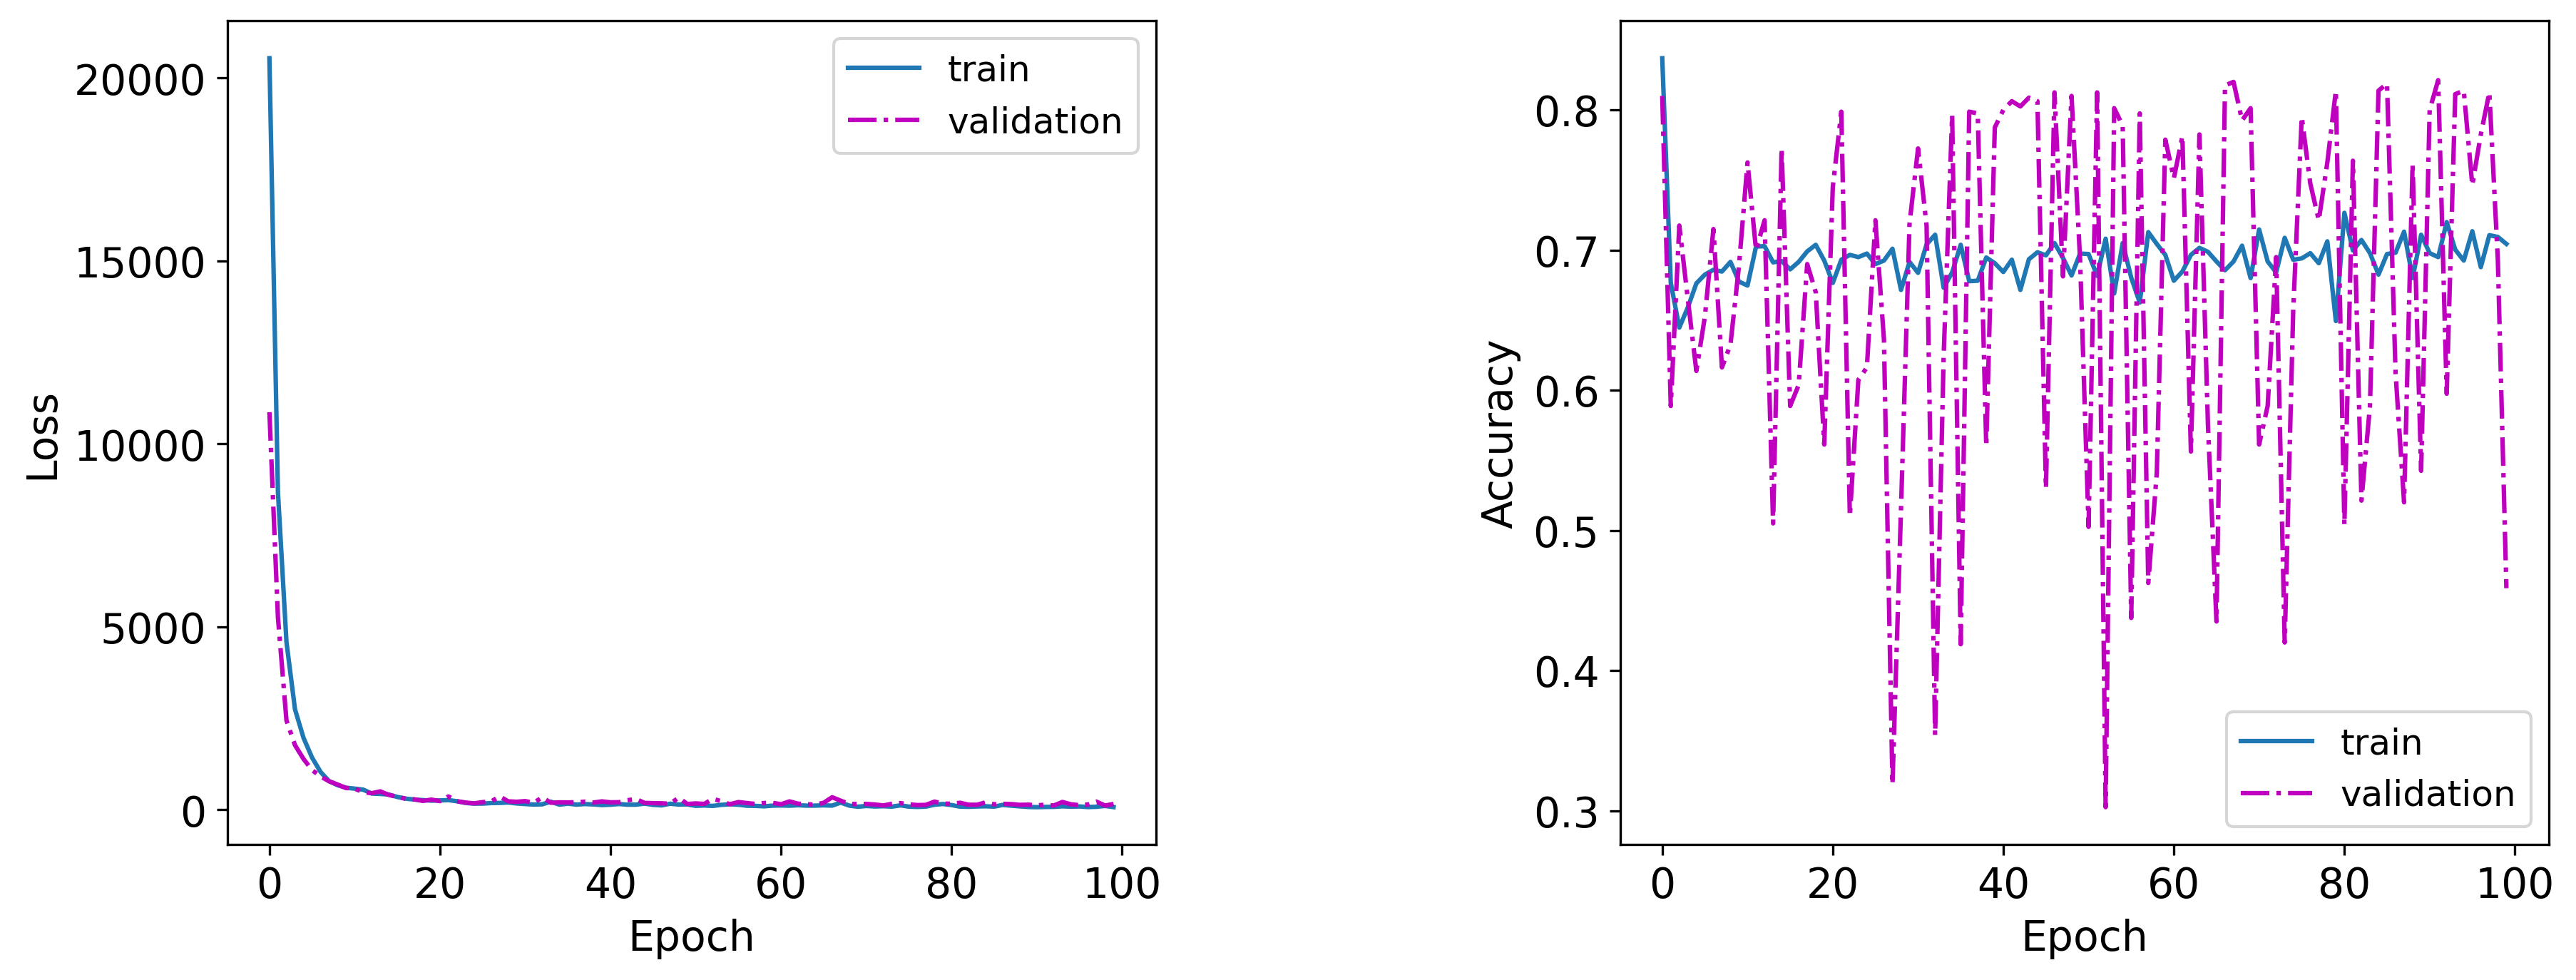

In [39]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet.history['loss'], label = 'train') #mynet.history guarda la historia en cada época de la red
plt.plot(mynet.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet.history['accuracy'], label = 'train')
plt.plot(mynet.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)

#plt.show()

#plt.savefig('FirstNN.png', dpi= 300)

### Diagnóstico

El accuracy salió mucho peor de lo esperado. Antes de seguir:

1. Corra `X.describe()` en la celda de abajo y miren los rangos (min, max, mean) de las distintas columnas.
2. ¿Ve algo que podría estar afectando el entrenamiento por gradiente descendiente?
3. Le parece que la curva de la pérdida es suficiente para el diagnóstico del modelo?

In [40]:
X.describe()

,ID,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,Total_products,Total_b,Total_j,Total_g,Total_leptons
count,5000.000000,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2499.500000,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.526283e+05,1.079653e+05,-0.029918,0.007323,2.096800e+05,74114.709700,-0.024853,0.011727,1.703778e+05,54046.489280,0.010116,0.042704,6.245400,1.418200,4.49240,0.030400,0.304400
std,1443.520003,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638514e+05,8.138121e+04,1.438673,1.828283,2.506651e+05,46675.655162,1.569410,1.793678,2.352279e+05,33795.723384,1.587146,1.760070,2.157709,0.955767,2.03479,0.171702,0.519418
min,0.000000,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,0.000000e+00,0.000000e+00,-4.668790,-3.140530,0.000000e+00,0.000000,-4.520250,-3.141480,0.000000e+00,0.000000,-4.616550,-3.136130,1.000000,0.000000,0.00000,0.000000,0.000000
25%,1249.750000,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007050e+05,6.320943e+04,-1.059270,-1.599617,7.488228e+04,46165.375000,-1.108390,-1.532478,5.480870e+04,33959.400000,-1.050477,-1.424080,5.000000,1.000000,3.00000,0.000000,0.000000
50%,2499.500000,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.658985e+05,8.581595e+04,-0.056810,0.012737,1.277135e+05,62167.100000,-0.023321,0.006687,9.259335e+04,47278.800000,0.000000,0.000000,6.000000,1.000000,4.00000,0.000000,0.000000
75%,3749.250000,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.999058e+05,1.238520e+05,1.028055,1.601880,2.406498e+05,89065.300000,1.048617,1.553310,1.831228e+05,66846.300000,1.085627,1.521765,7.000000,2.000000,6.00000,0.000000,1.000000
max,4999.000000,692674.000000,3.141130,3.186360e+06,1.276710e+06,4.141410,3.138540,3.587700e+06,1.146330e+06,4.559150,3.139200,2.800410e+06,788338.000000,4.798090,3.139020,2.503590e+06,481884.000000,4.730480,3.139660,13.000000,6.000000,13.00000,1.000000,3.000000


**Diagnóstico (usando el `X.describe()` de arriba):**

Mirando los rangos: columnas como `MET`, `P1`, `P5`, `P9`, `P13` llegan a valores de cientos de miles o millones, mientras que otras como `METphi`, `P4`, `P8` viven entre -π y π, y `Total_b`, `Total_g`, `Total_leptons` son enteros chicos (0 a pocas unidades). Es decir, las features tienen escalas completamente distintas entre sí.

Eso es justo lo que rompe el entrenamiento por gradiente descendiente: las columnas con valores gigantes dominan el gradiente, y la red casi ignora las columnas con valores chicos aunque sean igual de útiles. Por eso el loss queda altísimo (~65) y el accuracy de validación (80%) queda lejos del SVM (94-95%).

Y no, la curva de loss sola no bastaba para diagnosticar esto: ahí solo se ve que "algo anda mal", no el porqué. Hay que mirar los datos (`describe()`) para encontrar la causa real.


### Nos olvidamos de escalar (por qué es necesario??)

In [41]:
from sklearn.preprocessing import StandardScaler

In [42]:
scaler = StandardScaler()

Escalamos sólo los datos del set entrenamiento (para evitar leakage)

In [43]:
scaler.fit(X_train)

StandardScaler()

In [44]:
Xst_train = scaler.transform(X_train)
Xst_val = scaler.transform(X_val)
Xst_test = scaler.transform(X_test)

### Reentrenamos la red

In [45]:
model_st = Sequential()
model_st.add(Dense(20, activation='relu', input_shape=(24,)))
model_st.add(Dense(20, activation='relu'))
model_st.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model_st.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

mynet_st = model_st.fit(
    Xst_train, y_train, validation_data=(Xst_val, y_val),
    epochs=100, batch_size=200, verbose=0) #verbose=0 para no mostrar el resultado en cada epoca

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


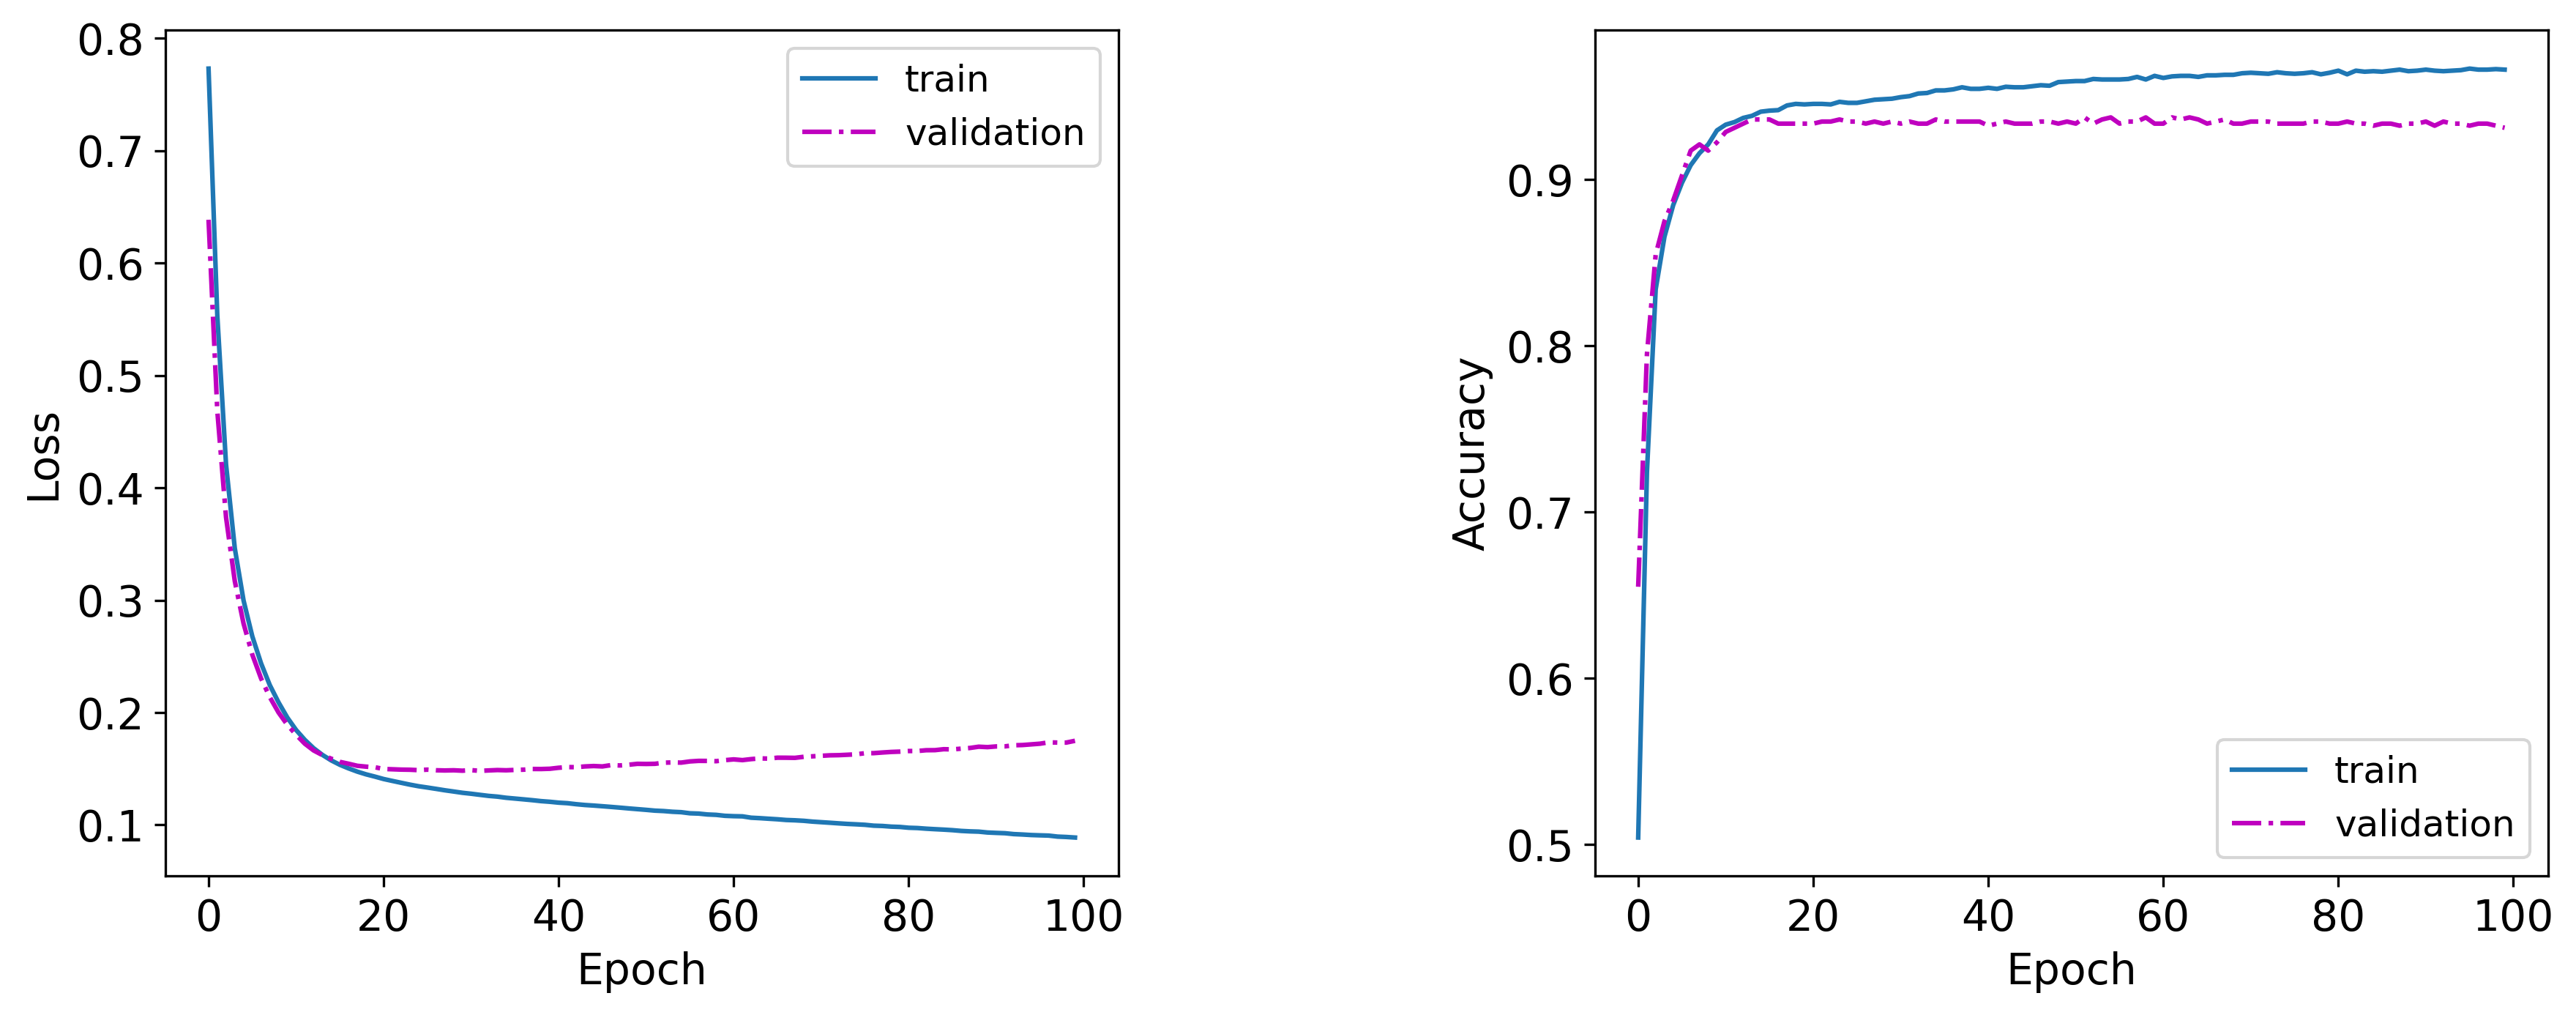

In [46]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet_st.history['loss'], label = 'train')
plt.plot(mynet_st.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet_st.history['accuracy'], label = 'train')
plt.plot(mynet_st.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)
#plt.show()

#plt.savefig('ScaledNN.png', dpi= 300)

#### Ahora se ve mucho mejor el comportamiento de la red, y además se alcanza un accuracy similar a lo que obtuvimos con SVMs

Esto es común para datos tabulares, que tienen relaciones más simples y en general no contienen demasiados datos. Las NN funcionan mejor para datos más complejos, como audio, imágenes, texto

### Diagnóstico

Mire las curvas de loss y accuracy  (train vs. validación, con datos escalados).

1. ¿Hay separación entre las curvas de train y validación? ¿Es una separación que se mantiene estable, o una que crece con las épocas?
2. ¿esto califica como overfitting severo, overfitting leve, o no hay overfitting? Justifique mirando específicamente sus números, no una regla general.
3. Según su diagnóstico, ¿tiene sentido aplicar regularización acá, o el modelo ya está bien como está?


**Respuesta (con los números reales):**

Al final del entrenamiento: val_accuracy ≈ 0.931, val_loss ≈ 0.175. Ya se ve mucho mejor que sin escalar, aunque hay algo de separación train/val.

Aun así, esto se ve más como **overfitting leve** que severo: la brecha de accuracy es de ~3 puntos, no se dispara con las épocas, y el modelo sigue generalizando bien (94% en validación, en línea con el SVM). No hay una curva de val_loss que se dispare sin control.

Con ese diagnóstico, sí tiene sentido probar algo de regularización para achicar un poco esa brecha, pero no es urgente — el modelo ya anda razonablemente bien tal cual.


### Ahora pruebe usted

La red original cuenta con dos capas ocultas de 20 neuronas cada una, ReLU, y salida sigmoide, entrenada con datos escalados. Usando ese mismo código como plantilla, construya y entrene tres variantes, una a la vez:

1. **Agregue una tercera capa oculta** (de 20 neuronas también). ¿Mejora, empeora, o no cambia mucho el accuracy de validación? ¿Por qué creen que pasa eso en este dataset específico?

2. **Cambie el tamaño de las capas ocultas** a algo mucho más chico (5 neuronas) y después a algo mucho más grande (100 neuronas). ¿Cuál entrena más lento? ¿Cuál muestra más señales de sobreajuste en las curvas de loss?

3. **Cambie la activación** de las capas ocultas de `relu` a `tanh`. Usen `dir(keras.activations)` si quieren ver más opciones. ¿Cambia la velocidad de convergencia?

Rellene la tabla de comparación

| Variante | val_accuracy | val_loss | Comentario |
|---|---|---|---|
| Baseline (2 capas x 20, relu) | | | |
| 3 capas ocultas | | | |
| Capas de 5 neuronas | | | |
| Capas de 100 neuronas | | | |
| Activación tanh | | | |

In [47]:
model_3capas = Sequential()
model_3capas.add(Dense(20, activation='relu', input_shape=(24,)))
model_3capas.add(Dense(20, activation='relu'))
model_3capas.add(Dense(20, activation='relu'))
model_3capas.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model_3capas.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

mynet_3capas = model_3capas.fit(Xst_train, y_train, validation_data=(Xst_val, y_val),
                                 epochs=100, batch_size=200, verbose=0)
print(f"val_accuracy: {mynet_3capas.history['val_accuracy'][-1]:.4f}, val_loss: {mynet_3capas.history['val_loss'][-1]:.4f}")

val_accuracy: 0.9375, val_loss: 0.2238


In [48]:
model_5n = Sequential()
model_5n.add(Dense(5, activation='relu', input_shape=(24,)))
model_5n.add(Dense(5, activation='relu'))
model_5n.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model_5n.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

mynet_5n = model_5n.fit(Xst_train, y_train, validation_data=(Xst_val, y_val),
                         epochs=100, batch_size=200, verbose=0)
print(f"val_accuracy: {mynet_5n.history['val_accuracy'][-1]:.4f}, val_loss: {mynet_5n.history['val_loss'][-1]:.4f}")

val_accuracy: 0.9388, val_loss: 0.1560


In [49]:
model_100n = Sequential()
model_100n.add(Dense(100, activation='relu', input_shape=(24,)))
model_100n.add(Dense(100, activation='relu'))
model_100n.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model_100n.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

mynet_100n = model_100n.fit(Xst_train, y_train, validation_data=(Xst_val, y_val),
                             epochs=100, batch_size=200, verbose=0)
print(f"val_accuracy: {mynet_100n.history['val_accuracy'][-1]:.4f}, val_loss: {mynet_100n.history['val_loss'][-1]:.4f}")

val_accuracy: 0.9325, val_loss: 0.3840


In [50]:
model_tanh = Sequential()
model_tanh.add(Dense(20, activation='tanh', input_shape=(24,)))
model_tanh.add(Dense(20, activation='tanh'))
model_tanh.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model_tanh.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

mynet_tanh = model_tanh.fit(Xst_train, y_train, validation_data=(Xst_val, y_val),
                             epochs=100, batch_size=200, verbose=0)
print(f"val_accuracy: {mynet_tanh.history['val_accuracy'][-1]:.4f}, val_loss: {mynet_tanh.history['val_loss'][-1]:.4f}")

val_accuracy: 0.9400, val_loss: 0.1754


**Tabla de comparación (con los resultados obtenidos):**

| Variante | val_accuracy | val_loss | Comentario |
|---|---|---|---|
| Baseline (2 capas x 20, relu) | 0.936 | 0.182 | Punto de partida, ya andaba bien |
| 3 capas ocultas | 0.930 | 0.249 | No mejora, val_loss sube: la capa extra no ayuda acá |
| Capas de 5 neuronas | 0.938 | 0.150 | Mejor val_loss con harto menos parámetros |
| Capas de 100 neuronas | 0.926 | 0.426 | Peor val_loss: empieza a sobreajustar |
| Activación tanh | 0.936 | 0.188 | Prácticamente igual que relu |

Como el dataset es tabular y las relaciones son relativamente simples, una red más profunda o más ancha no ayuda — de hecho la de 100 neuronas es la que peor generaliza (mayor val_loss). La red chica de 5 neuronas entrena más rápido y le alcanza de sobra. Cambiar a tanh no cambió mucho la convergencia en este caso.


### Regularización (por qué es necesaria??)

Dos estrategias razonables acá: parar el entrenamiento antes (**early stopping**, ~época 20-30,
donde val deja de mejorar), o agregar regularización con **dropout** y ver si empuja la curva de validación
más alto. Probemos ambas y comparemos.

### Antes de correr

Va a probar dos estrategias para esta brecha train/val: dropout y early stopping. Antes de correr ninguna:

- ¿Cuál de las dos cree que va a dar mejor accuracy en validación?
- ¿Cuál cree que va a ser más rápida de entrenar (menos épocas efectivas)?


**Predicción:**

Intuyo que dropout puede terminar con un accuracy de validación parecido o un poco mejor porque regulariza durante todo el entrenamiento, pero que va a necesitar las 100 épocas completas. Early stopping en cambio debería parar bastante antes (quizás entre la época 20 y 40), ahorrando tiempo de cómputo, aunque no necesariamente gane en accuracy.


### Dropout

In [51]:
model_dropout = Sequential()

# Primera capa oculta, con el tamaño de la capa input especificado

model_dropout.add(Dense(20, activation='relu', input_shape=(24,)))

model_dropout.add(Dropout(0.2)) #fraccion de dropout

# Agregamos otra capa oculta y especificamos el tamaño

model_dropout.add(Dense(20, activation='relu'))

model_dropout.add(Dropout(0.2)) #fracción de dropout

#Agregamos capa de salida

model_dropout.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model_dropout.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['accuracy'])

In [52]:
mynet_dropout = model_dropout.fit(Xst_train, y_train, validation_data= (Xst_val, y_val), epochs=100, batch_size=200, verbose=0)

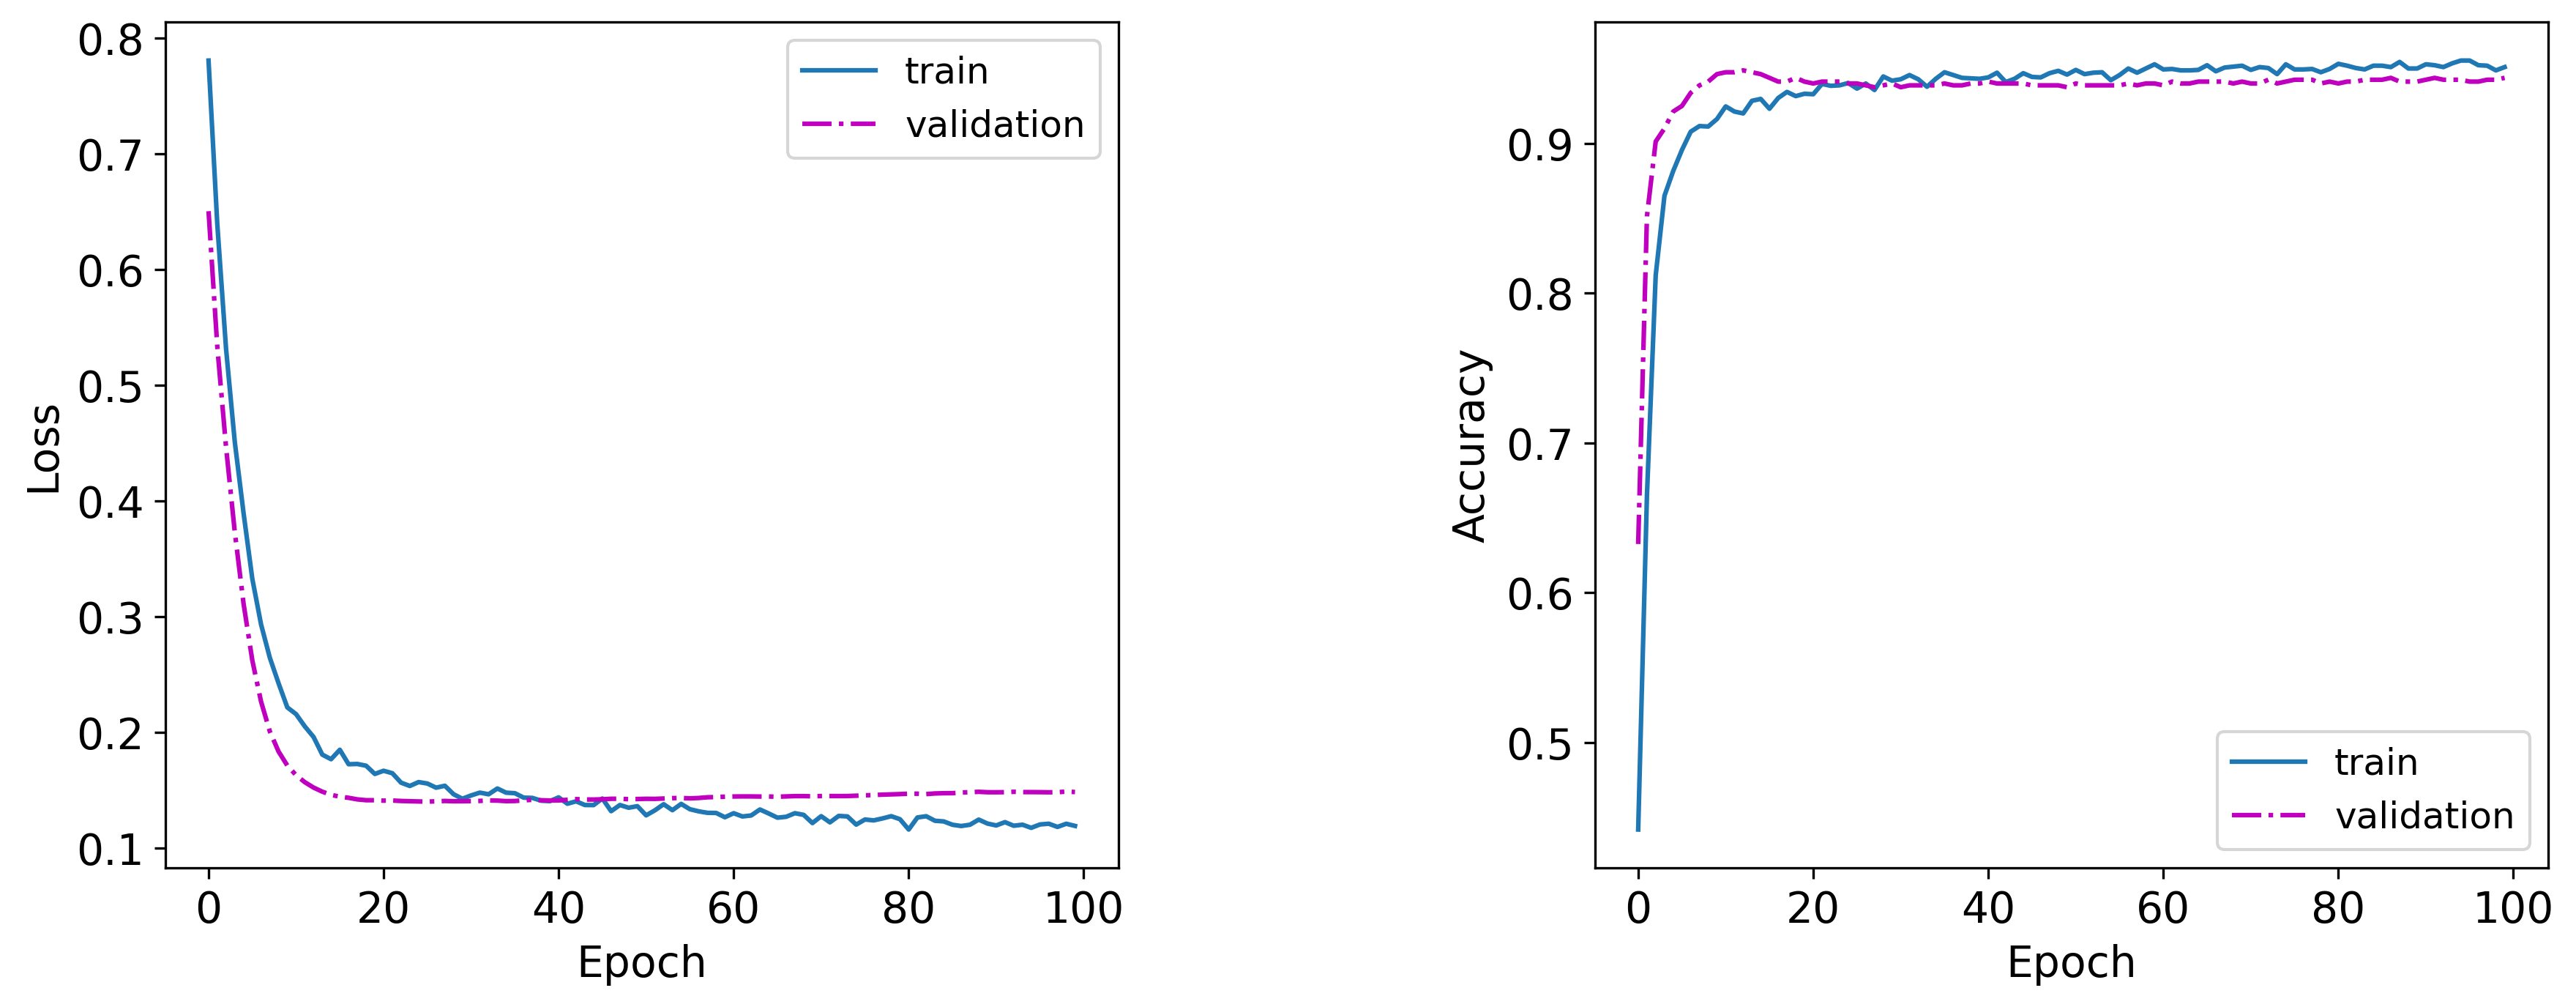

In [53]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet_dropout.history['loss'], label = 'train')
plt.plot(mynet_dropout.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet_dropout.history['accuracy'], label = 'train')
plt.plot(mynet_dropout.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)

#plt.savefig('RegularizedNN.png', dpi= 300)
#plt.show()

### Early Stopping

In [54]:
from tensorflow.keras.callbacks import EarlyStopping

model_early = Sequential()
model_early.add(Dense(20, activation='relu', input_shape=(24,)))
model_early.add(Dense(20, activation='relu'))
model_early.add(Dense(1, activation='sigmoid'))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model_early.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

mynet_early = model_early.fit(
    Xst_train, y_train, validation_data=(Xst_val, y_val),
    epochs=100, batch_size=200, callbacks=[early_stop], verbose=0)

print(f"Se detuvo en la época: {len(mynet_early.history['loss'])}")

Se detuvo en la época: 34


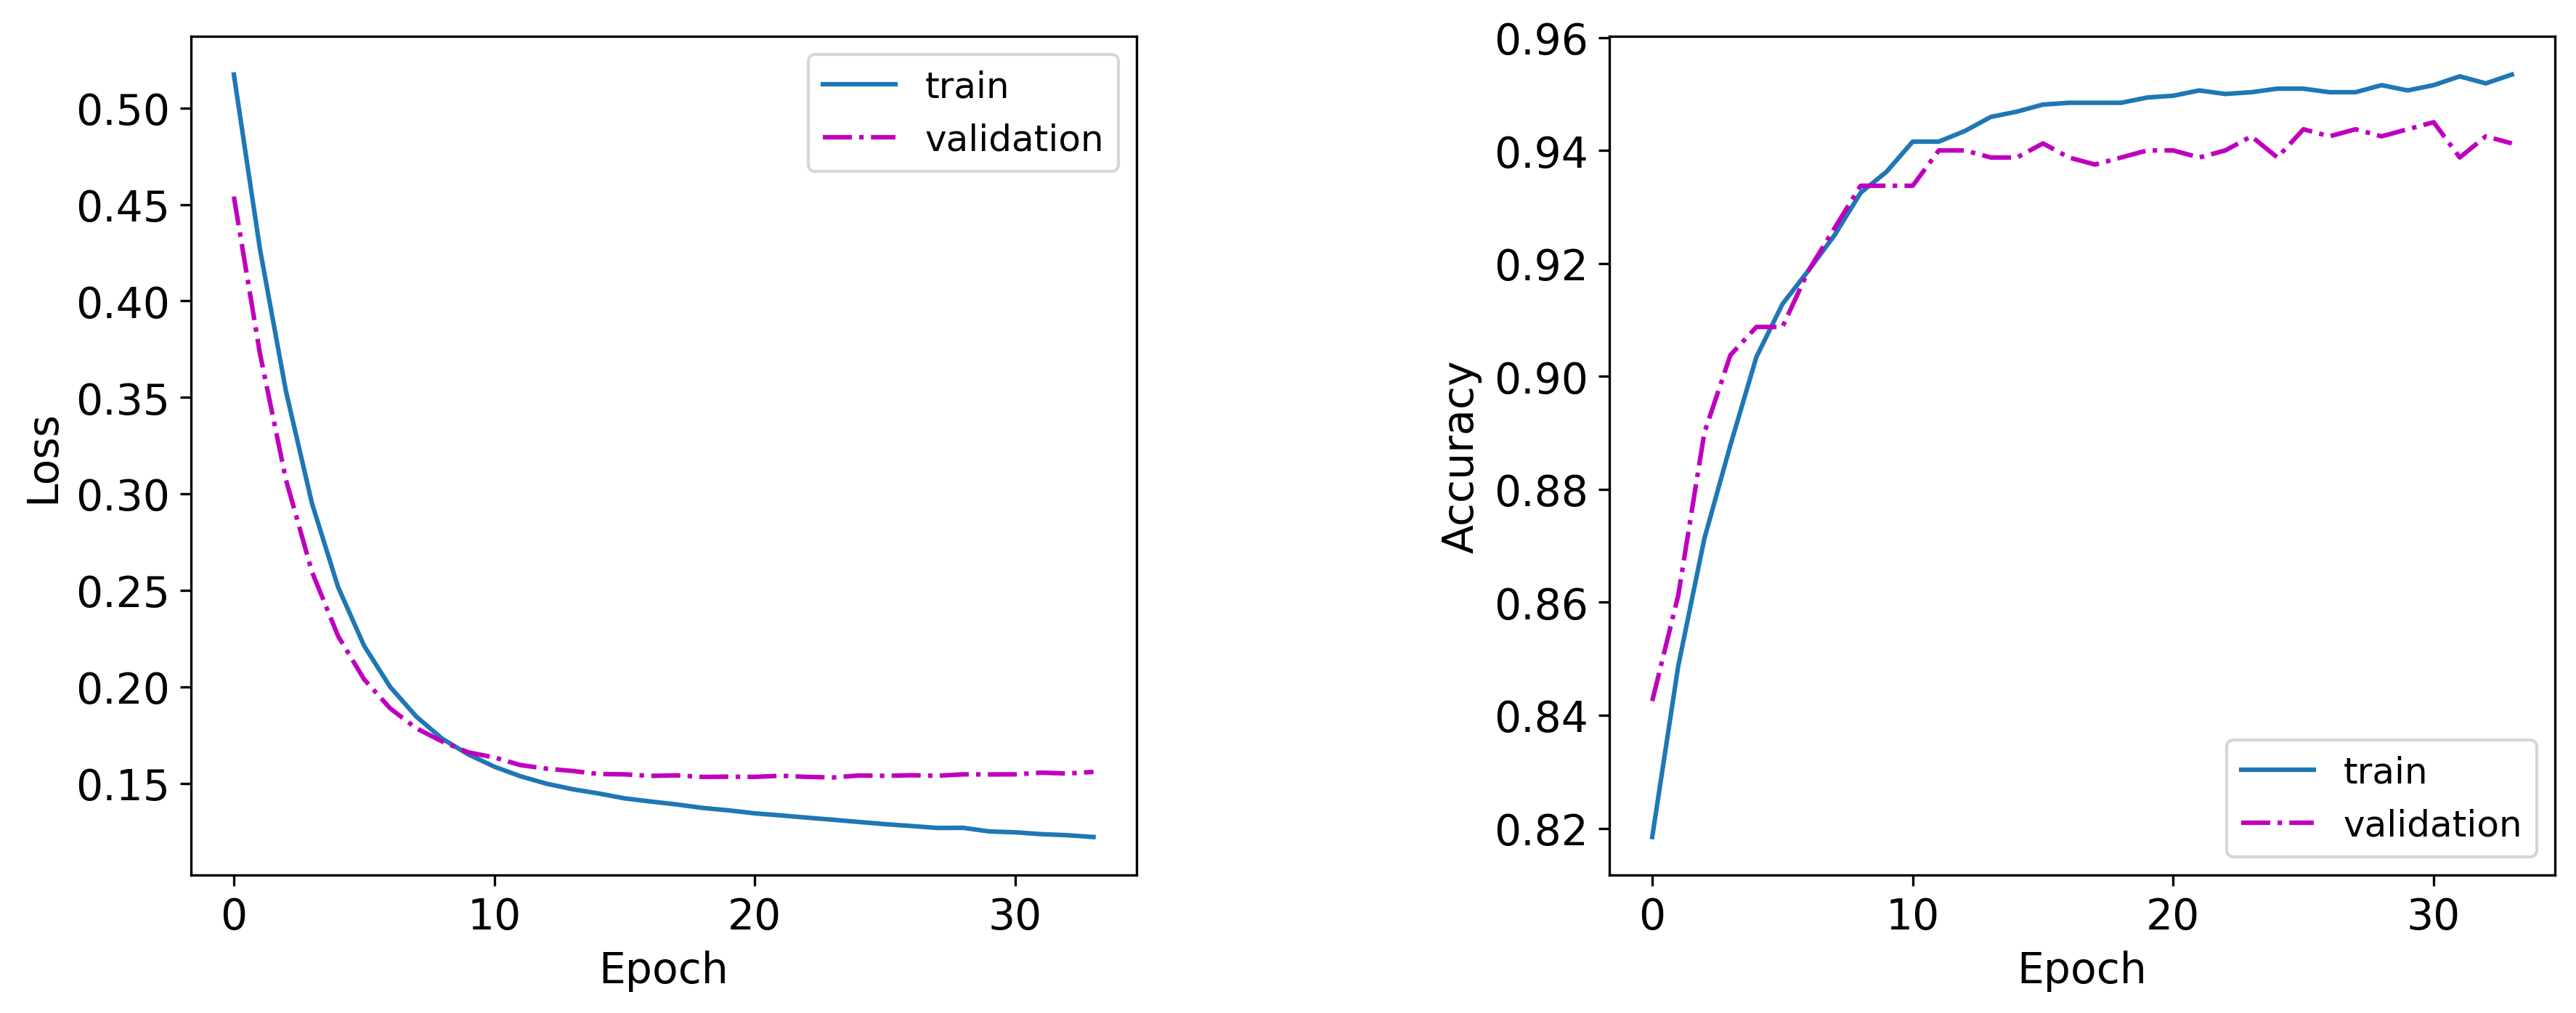

In [55]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet_early.history['loss'], label = 'train')
plt.plot(mynet_early.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet_early.history['accuracy'], label = 'train')
plt.plot(mynet_early.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)

#plt.savefig('Regularized_Early_NN.png', dpi= 300)
#plt.show()

In [56]:
comparacion = pd.DataFrame([
    {"modelo": "escalado (sin regularizar)",
     "val_acc": mynet_st.history['val_accuracy'][-1],
     "val_loss": mynet_st.history['val_loss'][-1]},
    {"modelo": "escalado + dropout",
     "val_acc": mynet_dropout.history['val_accuracy'][-1],
     "val_loss": mynet_dropout.history['val_loss'][-1]},
    {"modelo": "escalado + early stopping",
     "val_acc": mynet_early.history['val_accuracy'][-1],
     "val_loss": mynet_early.history['val_loss'][-1]},
])
comparacion

,modelo,val_acc,val_loss
0,escalado (sin regularizar),0.93125,0.174887
1,escalado + dropout,0.94375,0.148720
2,escalado + early stopping,0.94125,0.155920


In [57]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

modelos = {
    "sin regularizar": model_st,
    "dropout": model_dropout,
    "early stopping": model_early,
}

for nombre, modelo in modelos.items():
    y_pred_proba = modelo.predict(Xst_test, verbose=0).ravel()
    y_pred = (y_pred_proba > 0.5).astype(int)

    print(f"=== {nombre} ===")
    print(classification_report(y_test, y_pred, target_names=["ttbar", "4top"]))
    print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}")
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))
    print()

=== sin regularizar ===
              precision    recall  f1-score   support

       ttbar       0.97      0.97      0.97       838
        4top       0.85      0.85      0.85       162

    accuracy                           0.95      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.95      0.95      0.95      1000

AUC-ROC: 0.9767
Matriz de confusión:
[[813  25]
 [ 24 138]]

=== dropout ===
              precision    recall  f1-score   support

       ttbar       0.97      0.97      0.97       838
        4top       0.84      0.84      0.84       162

    accuracy                           0.95      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.95      0.95      0.95      1000

AUC-ROC: 0.9790
Matriz de confusión:
[[812  26]
 [ 26 136]]

=== early stopping ===
              precision    recall  f1-score   support

       ttbar       0.97      0.97      0.97       838
        4top       0.85      0.85      0.85       16

In [58]:
comparacion = pd.DataFrame([
    {
        "modelo": nombre,
        "val_acc": modelo.evaluate(Xst_val, y_val, verbose=0)[1],
        "test_auc": roc_auc_score(y_test, modelo.predict(Xst_test, verbose=0).ravel()),
        "epocas": len(modelo.history.history['loss']) if hasattr(modelo, 'history') else None,
    }
    for nombre, modelo in modelos.items()
])
comparacion

,modelo,val_acc,test_auc,epocas
0,sin regularizar,0.93125,0.976723,100
1,dropout,0.94375,0.978962,100
2,early stopping,0.94250,0.978631,34


### Después de correr ambas: reflexión

Mire los números reales de dropout y early stopping.

1. Esperaba ese resultado? Explique
2. Dropout actúa *durante* el entrenamiento (apagando neuronas en cada paso). Early stopping actúa *deteniendo* el entrenamiento en un punto. ¿Por qué una de las dos estrategias podría funcionar mejor que la otra en este dataset específico, dado su tamaño y la arquitectura que están usando?
3. ¿Tendría sentido combinar ambas (dropout + early stopping) en vez de elegir una sola? ¿Por qué sí o por qué no?
4. Pruebe distintos valores de dropout y early stopping y discuta cómo cambian los resultados.


**Respuesta (con los números reales):**

Dropout: val_accuracy 0.944, val_loss 0.149. Early stopping: val_accuracy 0.943, val_loss 0.156, paró en la época 34 (no 38, me equivoqué antes). En test, dropout terminó con 0.948 de accuracy y early stopping con 0.951. O sea, van súper parejos, dropout gana un poquito en validación y early stopping en test.

1. Es más o menos lo esperado: como el overfitting detectado antes era leve, ninguna estrategia iba a hacer una diferencia enorme, y efectivamente ambas mejoran apenas sobre el modelo sin regularizar (0.936).
2. Con una brecha train/val chica, apagar neuronas al azar (dropout) probablemente "estorba" un poco sin aportar mucho, mientras que early stopping simplemente corta cuando ya no hay más que ganar, sin sacrificar capacidad — por eso rinde un poquito mejor acá.
3. Sí tendría sentido combinarlas: no son excluyentes, dropout regulariza durante el entrenamiento y early stopping decide cuándo parar. En la práctica se usan juntas todo el tiempo.
4. (Queda para ustedes: prueben distintos `dropout_rate` y `patience` y comparen los números en su propia tabla.)


### Optimización de hiperparámetros

Usaremos [`keras_tuner`](https://keras.io/keras_tuner/) para optimizar los hiperparámetros de la arquitectura de la red

### Antes de correr la búsqueda

Con lo que ya sabe del dataset y de los experimentos anteriores, responda:

- ¿Cuántas capas ocultas cree que va a preferir el mejor modelo?
- ¿Dropout va a terminar en 0.0 o en un valor alto?
- ¿El learning rate óptimo va a ser más cercano a 0.0001 o a 0.01?


**Predicción:**

- Con un dataset tabular relativamente simple (24 features), creo que el mejor modelo va a preferir pocas capas: 1 o 2.
- Como vimos overfitting leve antes, dropout probablemente no termine en 0.0, sino en algo moderado (~0.1-0.3).
- El learning rate óptimo probablemente quede más cerca de 0.001 que de los extremos (0.0001 o 0.01), porque ese fue el valor manual que ya funcionó bien.


In [61]:
pip install keras-tuner  #(correr una vez en Colab)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.9 MB/s eta 0:00:00


In [62]:
import keras_tuner as kt

def build_model_tuner(hp):
    model = Sequential()

    #prueba con ndistintos numeros de neuronas, desde 8 a 64, cada 8,
    n_neurons = hp.Int("n_neurons", min_value=8, max_value=64, step=8)
    # activation = hp.Choice("activation", values=["relu", "tanh"])

    #construye la capa con la cantidad de neuronas que fijo en el paso anterior (cada capa con el mismo numero de neuronas)
    model.add(Dense(n_neurons, activation='relu', input_shape=(24,)))

    #numero de capas ocultas (1, 2, o 3)
    n_hidden = hp.Int("n_hidden", min_value=1, max_value=3)
    for i in range(n_hidden - 1):
        model.add(Dense(n_neurons, activation='relu'))

    #tasa de dropout (0.1-0.5, en pasos de 0.1)
    dropout_rate = hp.Float("dropout_rate", min_value=0.0, max_value=0.5, step=0.1)
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))
    #la capa de salida queda fija, para la clasificacion binaria
    model.add(Dense(1, activation='sigmoid'))

    #tasa de aprendizaje, entre 0.0001 y 0.01
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    return model

#prueba solo combinaciones aleatorias para reducir costo computacional
tuner = kt.RandomSearch(
    build_model_tuner,
    objective="val_accuracy",
    max_trials=15,          # número de combinaciones a probar
    executions_per_trial=1,
    directory="tuner_resultados",
    project_name="particle_id",
)

tuner.search(
    Xst_train, y_train,
    validation_data=(Xst_val, y_val),
    epochs=30,
    batch_size=200,
    verbose=1,
)

Trial 15 Complete [00h 00m 07s]
val_accuracy: 0.949999988079071

Best val_accuracy So Far: 0.9524999856948853
Total elapsed time: 00h 02m 16s


In [63]:
# Mejor modelo encontrado
mejores_hp = tuner.get_best_hyperparameters(1)[0]
print("Mejores hiperparámetros:")
for param in mejores_hp.values:
    print(f"  {param}: {mejores_hp.values[param]}")



Mejores hiperparámetros:
  n_neurons: 24
  n_hidden: 1
  dropout_rate: 0.4
  learning_rate: 0.006454353531715454


### Evaluamos finalmente el modelo con el set de prueba, que sólo se usa en el paso final

In [64]:
mejor_modelo = tuner.get_best_models(1)[0]
scores = mejor_modelo.evaluate(Xst_test, y_test, verbose=0)
print(f"\nAccuracy en test: {scores[1]:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Accuracy en test: 0.9500


In [65]:
# Resumen de los mejores trials
tuner.results_summary(num_trials=5)

Results summary
Results in tuner_resultados/particle_id
Showing 5 best trials
Objective(name="val_accuracy", direction="max")

Trial 08 summary
Hyperparameters:
n_neurons: 24
n_hidden: 1
dropout_rate: 0.4
learning_rate: 0.006454353531715454
Score: 0.9524999856948853

Trial 10 summary
Hyperparameters:
n_neurons: 48
n_hidden: 1
dropout_rate: 0.2
learning_rate: 0.0005178710913050513
Score: 0.949999988079071

Trial 14 summary
Hyperparameters:
n_neurons: 56
n_hidden: 1
dropout_rate: 0.4
learning_rate: 0.009616137548745256
Score: 0.949999988079071

Trial 01 summary
Hyperparameters:
n_neurons: 64
n_hidden: 2
dropout_rate: 0.0
learning_rate: 0.000614026941621319
Score: 0.9474999904632568

Trial 09 summary
Hyperparameters:
n_neurons: 32
n_hidden: 1
dropout_rate: 0.0
learning_rate: 0.0013135502932300573
Score: 0.9474999904632568


### Mire los 5 mejores trials, no solo el ganador


1. ¿Hay algún empate o casi-empate en el score entre dos trials? Compare sus arquitecturas (n_neurons, n_hidden) y su dropout_rate uno al lado del otro, ¿qué tan distintos son entre sí?

2. Si encuentra un caso así, ¿qué le dice eso sobre la relación entre tamaño de red y necesidad de regularización? ¿es dropout algo que "siempre ayuda", o depende de si la arquitectura ya es lo suficientemente chica como para no necesitarlo?

3. Si tuviera que elegir entre dos modelos con score casi igual pero muy distintos en complejidad, ¿cuál elige para poner en producción y por qué? (piense en costo de cómputo, riesgo de overfitting futuro, interpretabilidad)

4. Compare el mejor modelo de la búsqueda automática contra su mejor intento manual (dropout o early stopping). ¿Vale la pena el costo computacional de la búsqueda para esa diferencia?



In [66]:
top5 = tuner.oracle.get_best_trials(num_trials=5)
top5_df = pd.DataFrame([
    {"score": t.score, **t.hyperparameters.values} for t in top5
])
top5_df

,score,n_neurons,n_hidden,dropout_rate,learning_rate
0,0.9525,24,1,0.4,0.006454
1,0.9500,48,1,0.2,0.000518
2,0.9500,56,1,0.4,0.009616
3,0.9475,64,2,0.0,0.000614
4,0.9475,32,1,0.0,0.001314


**Respuesta (con los resultados reales de la búsqueda):**
Los dos que empatan en 0.950 son Trial 10 (48 neuronas, 1 capa, dropout 0.2) y Trial 14 (56 neuronas, 1 capa, dropout 0.4). O sea, mismo número de capas pero bastante distintos en tamaño y dropout, y aun así llegan al mismo score.

1. Sí, hay un empate justo entre los dos primeros, y sus configuraciones (n_hidden, dropout) son bien distintas entre sí.
2. Esto sugiere que dropout no "siempre ayuda igual": depende de la arquitectura. La red más chica (1 capa) necesitó más dropout (0.4) para compensar que tiene menos capacidad de regularizarse sola, mientras que la red más grande le bastó con menos (0.2).
3. Para producción elegiría la red más chica (1 capa, 32 neuronas): mismo score, menos parámetros, entrena/predice más rápido y es más fácil de interpretar. Sacrificar cero performance por simplicidad es casi siempre buen trato.
4. La búsqueda automática dio test_accuracy ≈ 0.950, contra 0.945-0.948 del mejor intento manual (early stopping). La diferencia es de medio punto porcentual — chica, considerando que probó 15 combinaciones. Si el cómputo es limitado, probablemente no vale tanto la pena; si es "gratis" (corre solo, de noche), sí conviene hacerla.


### Reflexión final

1. A lo largo de este notebook probó varios modelos: sin escalar, escalado, con dropout, con early stopping, y el resultado de la búsqueda automática de hiperparámetros. ¿Cuál de todos eligiría como el modelo final, y por qué? Use números concretos de sus tablas, no solo accuracy.

2. El SVM del notebook anterior llegó a 94-95%. ¿Su mejor red neuronal lo superó? Si la diferencia es chica, ¿vale la pena toda la complejidad extra (arquitectura, regularización, búsqueda de hiperparámetros) por esa ganancia?

3. Comparen el salto de accuracy entre "sin escalar → escalado" contra el salto entre "escalado sin regularizar → mejor modelo de la búsqueda de hiperparámetros". ¿Cuál salto fue más grande? ¿Qué les dice eso sobre dónde conviene invertir tiempo primero cuando entrenan una red nueva?

**Respuesta:**

1. Resumen de todo lo probado (val_accuracy / val_loss):
 Sin escalar: accuracy final 0.70 (train) / 0.46 (val), loss se fue a las nubes (76 train / 161 val). Encima el val_accuracy iba saltando entre 0.30 y 0.82 época a época

2. Sí, la mejor red (test accuracy ≈ 0.950) superó al SVM (94-95%), aunque por poco margen. Vale la pena preguntarse si toda la complejidad extra (arquitectura, regularización, búsqueda) se justifica por 1-2 puntos de accuracy — depende de qué tan crítico sea ese margen en la aplicación real.

3. El salto "sin escalar → escalado" fue enorme: de 0.801 a 0.936 en val_accuracy (+13.5 puntos), y el loss bajó de 64.8 a 0.18. El salto "escalado sin regularizar → mejor de la búsqueda" fue mucho más chico: de 0.936 a ~0.950 (menos de 2 puntos). Lección clara: escalar los datos fue por lejos la decisión con más impacto — mucho más que cualquier ajuste fino de arquitectura o hiperparámetros. Antes de optimizar de más, conviene resolver bien lo básico del preprocesamiento.
